Input: MNIST image 1 × 28 × 28

Conv2D → ReLU → MaxPool

Learn low-level features

Conv2D → ReLU → MaxPool

Learn more complex features

Flatten → Dense → ReLU → Dropout

Dense → 10 class scores

Softmax cross-entropy → Backpropagation → Adam update

In [2]:
import gzip
import struct
import time
import urllib.request
from pathlib import Path

import numpy as np


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):
    np.random.seed(seed)


# ============================================================
# 2. DOWNLOAD AND LOAD MNIST
# ============================================================

MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"

MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}


def download_file(filename, data_dir):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    path = data_dir / filename

    if not path.exists():
        url = MNIST_URL + filename
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, path)

    return path


def load_mnist(data_dir="data/mnist"):
    paths = {
        key: download_file(filename, data_dir)
        for key, filename in MNIST_FILES.items()
    }

    # Load training images.
    with gzip.open(paths["train_images"], "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        assert magic == 2051
        x_train = np.frombuffer(
            f.read(), dtype=np.uint8
        ).reshape(n, rows, cols)

    # Load training labels.
    with gzip.open(paths["train_labels"], "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        assert magic == 2049
        y_train = np.frombuffer(
            f.read(), dtype=np.uint8
        ).copy()

    # Load test images.
    with gzip.open(paths["test_images"], "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        assert magic == 2051
        x_test = np.frombuffer(
            f.read(), dtype=np.uint8
        ).reshape(n, rows, cols)

    # Load test labels.
    with gzip.open(paths["test_labels"], "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        assert magic == 2049
        y_test = np.frombuffer(
            f.read(), dtype=np.uint8
        ).copy()

    # Convert images to float32 in [0, 1].
    # Shape: (N, 1, 28, 28).
    x_train = x_train[:, None, :, :].astype(np.float32) / 255.0
    x_test = x_test[:, None, :, :].astype(np.float32) / 255.0

    return (
        x_train,
        y_train.astype(np.int64),
        x_test,
        y_test.astype(np.int64),
    )


def train_validation_split(x, y, validation_size=5000, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(x))

    val_idx = indices[:validation_size]
    train_idx = indices[validation_size:]

    return (
        x[train_idx],
        y[train_idx],
        x[val_idx],
        y[val_idx],
    )

In [3]:

# ============================================================
# 3. CONVOLUTION HELPERS
# ============================================================

def im2col(x, kernel_size, stride=1, padding=0):
    """
    Input:
        x: (N, C, H, W)

    Returns:
        cols: flattened image patches
        (out_h, out_w)
    """
    n, c, h, w = x.shape
    k = kernel_size

    x_pad = np.pad(
        x,
        (
            (0, 0),
            (0, 0),
            (padding, padding),
            (padding, padding),
        ),
        mode="constant",
    )

    out_h = (h + 2 * padding - k) // stride + 1
    out_w = (w + 2 * padding - k) // stride + 1

    windows = np.lib.stride_tricks.sliding_window_view(
        x_pad, (k, k), axis=(2, 3)
    )

    windows = windows[:, :, ::stride, ::stride, :, :]

    # (N, C, out_h, out_w, K, K)
    # -> (N * out_h * out_w, C * K * K)
    cols = windows.transpose(
        0, 2, 3, 1, 4, 5
    ).reshape(
        n * out_h * out_w,
        c * k * k,
    )

    return cols, (out_h, out_w)


def col2im(cols, input_shape, kernel_size, stride=1, padding=0):
    """
    Scatter patch gradients back into the original image shape.
    Overlapping patch gradients are added together.
    """
    n, c, h, w = input_shape
    k = kernel_size

    out_h = (h + 2 * padding - k) // stride + 1
    out_w = (w + 2 * padding - k) // stride + 1

    cols = cols.reshape(
        n, out_h, out_w, c, k, k
    )

    dx_pad = np.zeros(
        (n, c, h + 2 * padding, w + 2 * padding),
        dtype=cols.dtype,
    )

    for ky in range(k):
        for kx in range(k):
            dx_pad[
                :,
                :,
                ky:ky + out_h * stride:stride,
                kx:kx + out_w * stride:stride,
            ] += cols[:, :, :, :, ky, kx].transpose(
                0, 3, 1, 2
            )

    if padding > 0:
        return dx_pad[
            :, :, padding:-padding, padding:-padding
        ]

    return dx_pad


# ============================================================
# 4. CONVOLUTIONAL LAYER
# ============================================================

class Conv2D:
    """
    NumPy convolution layer.

    Input:  (N, in_channels, H, W)
    Output: (N, out_channels, out_h, out_w)

    This operation uses cross-correlation, which is the
    standard convention for CNN convolution layers.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        padding=0,
    ):
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        fan_in = in_channels * kernel_size * kernel_size

        # He initialization for ReLU-based networks.
        self.W = (
            np.random.randn(
                out_channels, fan_in
            ).astype(np.float32)
            * np.sqrt(2.0 / fan_in)
        )

        self.b = np.zeros(out_channels, dtype=np.float32)

        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        self.cache = None
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape

        cols, (out_h, out_w) = im2col(
            x,
            self.kernel_size,
            self.stride,
            self.padding,
        )

        # Matrix multiplication performs the convolution.
        out = cols @ self.W.T + self.b

        n = x.shape[0]

        out = out.reshape(
            n, out_h, out_w, -1
        ).transpose(0, 3, 1, 2)

        self.cache = cols

        return out

    def backward(self, dout):
        cols = self.cache

        # (N, filters, out_h, out_w)
        # -> (N * out_h * out_w, filters)
        dout_rows = dout.transpose(
            0, 2, 3, 1
        ).reshape(-1, dout.shape[1])

        # Gradients for filters and biases.
        self.dW = dout_rows.T @ cols
        self.db = dout_rows.sum(axis=0)

        # Gradient with respect to the input patches.
        dcols = dout_rows @ self.W

        dx = col2im(
            dcols,
            self.input_shape,
            self.kernel_size,
            self.stride,
            self.padding,
        )

        return dx

    def parameters_and_grads(self):
        return [
            (self.W, self.dW),
            (self.b, self.db),
        ]

In [4]:

# ============================================================
# 5. RELU ACTIVATION
# ============================================================

class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = x > 0
        return np.maximum(x, 0)

    def backward(self, dout):
        return dout * self.mask


# ============================================================
# 6. MAX POOLING
# ============================================================

class MaxPool2D:
    """
    Max pooling for tensors shaped (N, C, H, W).
    """

    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.cache = None

    def forward(self, x):
        n, c, h, w = x.shape
        k = self.kernel_size
        s = self.stride

        out_h = (h - k) // s + 1
        out_w = (w - k) // s + 1

        windows = np.lib.stride_tricks.sliding_window_view(
            x, (k, k), axis=(2, 3)
        )[:, :, ::s, ::s, :, :]

        # (N, C, out_h, out_w, K*K)
        flat = windows.reshape(
            n, c, out_h, out_w, k * k
        )

        # Remember which element won each pooling window.
        argmax = flat.argmax(axis=-1)

        out = flat.max(axis=-1)

        self.cache = (x.shape, argmax, out_h, out_w)

        return out

    def backward(self, dout):
        input_shape, argmax, out_h, out_w = self.cache

        n, c, h, w = input_shape
        k = self.kernel_size
        s = self.stride

        dx = np.zeros(input_shape, dtype=dout.dtype)

        # Route each gradient to the maximum element.
        for ky in range(k):
            for kx in range(k):
                mask = argmax == (ky * k + kx)
                contribution = dout * mask

                dx[
                    :,
                    :,
                    ky:ky + out_h * s:s,
                    kx:kx + out_w * s:s,
                ] += contribution

        return dx


# ============================================================
# 7. FLATTEN
# ============================================================

class Flatten:
    def __init__(self):
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self.input_shape)


# ============================================================
# 8. FULLY CONNECTED LAYER
# ============================================================

class Dense:
    def __init__(self, in_features, out_features, relu_after=False):
        if relu_after:
            scale = np.sqrt(2.0 / in_features)
        else:
            scale = np.sqrt(1.0 / in_features)

        self.W = (
            np.random.randn(
                in_features, out_features
            ).astype(np.float32) * scale
        )

        self.b = np.zeros(out_features, dtype=np.float32)

        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW = self.x.T @ dout
        self.db = dout.sum(axis=0)

        dx = dout @ self.W.T

        return dx

    def parameters_and_grads(self):
        return [
            (self.W, self.dW),
            (self.b, self.db),
        ]


# ============================================================
# 9. DROPOUT
# ============================================================

class Dropout:
    """
    Inverted dropout.

    p = probability of dropping an activation.
    """

    def __init__(self, p=0.5):
        if not 0 <= p < 1:
            raise ValueError("p must satisfy 0 <= p < 1")

        self.p = p
        self.mask = None
        self.training = True

    def forward(self, x, training=True):
        self.training = training

        if not training or self.p == 0:
            self.mask = None
            return x

        keep_prob = 1.0 - self.p

        self.mask = (
            np.random.random(x.shape) < keep_prob
        ).astype(x.dtype) / keep_prob

        return x * self.mask

    def backward(self, dout):
        if not self.training or self.mask is None:
            return dout

        return dout * self.mask

In [5]:

# ============================================================
# 10. SOFTMAX CROSS-ENTROPY LOSS
# ============================================================

def softmax_cross_entropy(logits, y):
    """
    logits: (N, num_classes)
    y:      (N,) integer class labels

    Returns:
        mean loss
        gradient of mean loss with respect to logits
    """

    # Numerically stable softmax.
    shifted = logits - logits.max(axis=1, keepdims=True)

    exp_scores = np.exp(shifted)

    probs = exp_scores / exp_scores.sum(
        axis=1, keepdims=True
    )

    n = logits.shape[0]

    correct_probs = probs[np.arange(n), y]

    loss = -np.log(
        np.clip(correct_probs, 1e-12, 1.0)
    ).mean()

    # Gradient of softmax cross-entropy.
    dlogits = probs.copy()
    dlogits[np.arange(n), y] -= 1.0
    dlogits /= n

    return float(loss), dlogits


def accuracy(logits, y):
    predictions = logits.argmax(axis=1)
    return float(np.mean(predictions == y))

In [6]:

# ============================================================
# 11. COMPLETE CNN MODEL
# ============================================================

class NumpyCNN:
    def __init__(self, num_classes=10, dropout_p=0.5):

        # Block 1: 28x28 -> 28x28 -> 14x14
        self.conv1 = Conv2D(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.relu1 = ReLU()
        self.pool1 = MaxPool2D(kernel_size=2, stride=2)

        # Block 2: 14x14 -> 14x14 -> 7x7
        self.conv2 = Conv2D(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.relu2 = ReLU()
        self.pool2 = MaxPool2D(kernel_size=2, stride=2)

        # Classification head.
        self.flatten = Flatten()
        self.fc1 = Dense(
            in_features=16 * 7 * 7,
            out_features=64,
            relu_after=True,
        )
        self.relu3 = ReLU()
        self.dropout = Dropout(p=dropout_p)
        self.fc2 = Dense(
            in_features=64,
            out_features=num_classes,
        )

        self.layers = [
            self.conv1,
            self.conv2,
            self.fc1,
            self.fc2,
        ]

    def forward(self, x, training=True):
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)

        x = self.conv2.forward(x)
        x = self.relu2.forward(x)
        x = self.pool2.forward(x)

        x = self.flatten.forward(x)
        x = self.fc1.forward(x)
        x = self.relu3.forward(x)
        x = self.dropout.forward(x, training=training)

        logits = self.fc2.forward(x)

        return logits

    def backward(self, dlogits):
        grad = self.fc2.backward(dlogits)

        grad = self.dropout.backward(grad)
        grad = self.relu3.backward(grad)
        grad = self.fc1.backward(grad)
        grad = self.flatten.backward(grad)

        grad = self.pool2.backward(grad)
        grad = self.relu2.backward(grad)
        grad = self.conv2.backward(grad)

        grad = self.pool1.backward(grad)
        grad = self.relu1.backward(grad)
        self.conv1.backward(grad)

    def parameters_and_grads(self):
        result = []

        for layer in self.layers:
            result.extend(layer.parameters_and_grads())

        return result

    def predict(self, x, batch_size=256):
        predictions = []

        for start in range(0, len(x), batch_size):
            xb = x[start:start + batch_size]

            logits = self.forward(xb, training=False)

            predictions.append(logits.argmax(axis=1))

        return np.concatenate(predictions)

    def save(self, path="numpy_cnn_weights.npz"):
        np.savez(
            path,
            conv1_W=self.conv1.W,
            conv1_b=self.conv1.b,
            conv2_W=self.conv2.W,
            conv2_b=self.conv2.b,
            fc1_W=self.fc1.W,
            fc1_b=self.fc1.b,
            fc2_W=self.fc2.W,
            fc2_b=self.fc2.b,
        )
        print(f"Saved weights to {path}")

    def load(self, path="numpy_cnn_weights.npz"):
        with np.load(path) as data:
            for name in ("conv1", "conv2", "fc1", "fc2"):
                layer = getattr(self, name)
                layer.W[...] = data[f"{name}_W"]
                layer.b[...] = data[f"{name}_b"]

In [7]:

# ============================================================
# 12. ADAM OPTIMIZER
# ============================================================

class Adam:
    def __init__(
        self,
        learning_rate=1e-3,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
    ):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        self.t = 0
        self.m = None
        self.v = None

    def step(self, params_and_grads):
        if self.m is None:
            self.m = [
                np.zeros_like(param)
                for param, grad in params_and_grads
            ]
            self.v = [
                np.zeros_like(param)
                for param, grad in params_and_grads
            ]

        self.t += 1

        for i, (param, grad) in enumerate(params_and_grads):
            # First moment: moving average of gradients.
            self.m[i] = (
                self.beta1 * self.m[i]
                + (1 - self.beta1) * grad
            )

            # Second moment: moving average of squared gradients.
            self.v[i] = (
                self.beta2 * self.v[i]
                + (1 - self.beta2) * (grad * grad)
            )

            # Bias correction.
            m_hat = self.m[i] / (
                1 - self.beta1 ** self.t
            )

            v_hat = self.v[i] / (
                1 - self.beta2 ** self.t
            )

            # Update parameters in place.
            param -= (
                self.learning_rate
                * m_hat
                / (np.sqrt(v_hat) + self.epsilon)
            )

In [8]:

# ============================================================
# 13. EVALUATION
# ============================================================

def evaluate(model, x, y, batch_size=128):
    total_loss = 0.0
    total_correct = 0
    total = len(x)

    for start in range(0, total, batch_size):
        xb = x[start:start + batch_size]
        yb = y[start:start + batch_size]

        logits = model.forward(xb, training=False)

        loss, _ = softmax_cross_entropy(logits, yb)

        total_loss += loss * len(xb)

        total_correct += int(
            (logits.argmax(axis=1) == yb).sum()
        )

    return total_loss / total, total_correct / total


# ============================================================
# 14. TRAINING LOOP
# ============================================================

def train(
    model,
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=5,
    batch_size=64,
    learning_rate=1e-3,
    seed=42,
):
    rng = np.random.default_rng(seed)

    optimizer = Adam(learning_rate=learning_rate)

    n = len(x_train)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        # Shuffle the training examples every epoch.
        indices = rng.permutation(n)

        running_loss = 0.0
        running_correct = 0
        seen = 0

        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]

            xb = x_train[batch_idx]
            yb = y_train[batch_idx]

            # 1. Forward pass.
            logits = model.forward(xb, training=True)

            # 2. Calculate loss and gradient.
            loss, dlogits = softmax_cross_entropy(logits, yb)

            # 3. Backpropagation.
            model.backward(dlogits)

            # 4. Update weights.
            optimizer.step(model.parameters_and_grads())

            running_loss += loss * len(xb)

            running_correct += int(
                (logits.argmax(axis=1) == yb).sum()
            )

            seen += len(xb)

        train_loss = running_loss / seen
        train_acc = running_correct / seen

        # Dropout is disabled during validation.
        val_loss, val_acc = evaluate(model, x_val, y_val)

        elapsed = time.time() - start_time

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val acc: {val_acc:.4f} | "
            f"time: {elapsed:.1f}s"
        )

    return model

In [10]:
import matplotlib.pyplot as plt

def show_images(images, labels, num_images=10):
    """
    Display handwritten digit images from MNIST.

    images shape: (N, 1, 28, 28)
    labels shape: (N,)
    """

    plt.figure(figsize=(15, 3))

    for i in range(num_images):
        # Create one subplot for each image
        plt.subplot(1, num_images, i + 1)

        # Remove the channel dimension:
        # (1, 28, 28) -> (28, 28)
        image = images[i, 0]

        # Display the image in grayscale
        plt.imshow(image, cmap="gray")

        # Display the correct label
        plt.title(f"Label: {labels[i]}")

        # Hide axis numbers
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
def show_predictions(model, images, labels, num_images=10):
    # Get predictions from your NumPy CNN
    predictions = model.predict(images[:num_images])

    plt.figure(figsize=(15, 3))

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        image = images[i, 0]
        predicted_label = predictions[i]
        true_label = labels[i]

        plt.imshow(image, cmap="gray")

        # Green title if correct, red if incorrect
        color = "green" if predicted_label == true_label else "red"

        plt.title(
            f"Pred: {predicted_label}\nTrue: {true_label}",
            color=color
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

Loading MNIST dataset...


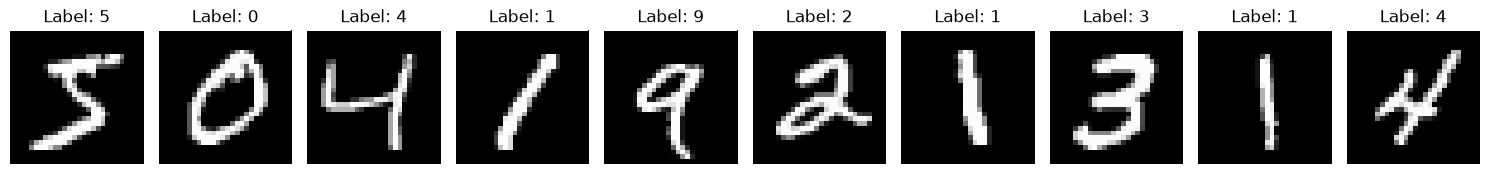

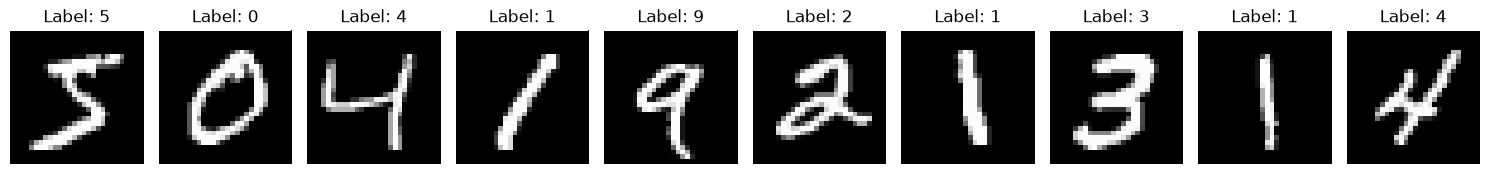

Training data: (55000, 1, 28, 28)
Validation data: (5000, 1, 28, 28)
Test data: (10000, 1, 28, 28)


In [ ]:

# ============================================================
# 15. MAIN PROGRAM
# ============================================================

def main():
    set_seed(42)

    print("Loading MNIST dataset...")

    x_train_all, y_train_all, x_test, y_test = load_mnist()

    # Keep the official test set separate until final evaluation.
    x_train, y_train, x_val, y_val = train_validation_split(
        x_train_all,
        y_train_all,
        validation_size=5000,
        seed=42,
    )

    # Load MNIST
    X_train, y_train, X_test, y_test = load_mnist()

    # Display 10 training images
    show_images(X_train, y_train, num_images=10)

    # Load MNIST
    X_train, y_train, X_test, y_test = load_mnist()

    # Display 10 training images
    show_images(X_train, y_train, num_images=10)

    # Uncomment these lines for a faster first experiment.
    # x_train, y_train = x_train[:10000], y_train[:10000]
    # x_val, y_val = x_val[:2000], y_val[:2000]

    print("Training data:", x_train.shape)
    print("Validation data:", x_val.shape)
    print("Test data:", x_test.shape)

    model = NumpyCNN(
        num_classes=10,
        dropout_p=0.5,
    )

    train(
        model,
        x_train,
        y_train,
        x_val,
        y_val,
        epochs=5,
        batch_size=64,
        learning_rate=1e-3,
    )

    # Evaluate on the untouched test set.
    test_loss, test_acc = evaluate(
        model,
        x_test,
        y_test,
    )

    print("\nFinal test results")
    print("------------------")
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    # Save learned parameters.
    model.save("numpy_cnn_mnist_weights.npz")

    # Show a few predictions.
    logits = model.forward(x_test[:10], training=False)
    predictions = logits.argmax(axis=1)

    print("\nTrue labels:     ", y_test[:10].tolist())
    print("Predictions:     ", predictions.tolist())

    show_predictions(model, X_test, y_test, num_images=10)


if __name__ == "__main__":
    main()